In [2]:


import requests, bs4, pandas, matplotlib
print("Todo OK")





import requests
from bs4 import BeautifulSoup

url = "https://books.toscrape.com/"
response = requests.get(url)

# Comprueba que todo fue bien
print(response.status_code)  # debe imprimir 200
print(response.text[:500])    # primeros 500 chars del HTML

Todo OK
200
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" /


In [3]:
soup = BeautifulSoup(response.text, "html.parser") 
print(soup.title.text) # imprime el título de la página


    All products | Books to Scrape - Sandbox



SELECCIONAR LIBROS

In [4]:
rating_map = {"One":1, "Two":2, "Three":3,
               "Four":4, "Five":5}
libros = []

for art in soup.select("article.product_pod"):
    titulo = art.select_one("h3 a")["title"]
    precio = art.select_one("p.price_color").text.strip()
    r_clase = art.select_one("p.star-rating")["class"][1]
    rating  = rating_map.get(r_clase, 0)
    stock   = art.select_one("p.availability").text.strip()

    libros.append({
        "titulo": titulo,
        "precio": precio,
        "rating": rating,
        "stock": stock
        
    })

print(f"Extraídos {len(libros)} libros")
print(libros[0])

Extraídos 20 libros
{'titulo': 'A Light in the Attic', 'precio': 'Â£51.77', 'rating': 3, 'stock': 'In stock'}


In [5]:
import time

BASE = "https://books.toscrape.com/catalogue/"
url  = "https://books.toscrape.com/catalogue/page-1.html"
todos = []

while url:
    r    = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")

    for art in soup.select("article.product_pod"):
        titulo = art.select_one("h3 a")["title"]
        precio = art.select_one("p.price_color").text.strip()
        r_clase = art.select_one("p.star-rating")["class"][1]
        rating  = rating_map.get(r_clase, 0)
        stock   = art.select_one("p.availability").text.strip()

        todos.append({
            "titulo": titulo,
            "precio": precio,
            "rating": rating,
            "stock": stock
    })

# busca el enlace "next"
    sig = soup.select_one("li.next a")
    url = BASE + sig["href"] if sig else None
    time.sleep(0.5)  # pausa entre peticiones

print(f"Total: {len(todos)} libros")  # debe dar 1000

Total: 1000 libros


EXPORTAR DATOS A CSV 

In [6]:
import pandas as pd
df = pd.DataFrame(todos)
#Limpia el precio: "Â£51.77" → 51.77
df["precio_num"] = (df["precio"] 
    .str.replace(r"[^\d.]", "", regex=True) 
    .astype(float)) 
print(df.head())

display(df.describe())
df.to_csv("libros.csv", index=False, encoding="utf-8-sig")
print("✅ Guardado en libros.csv")


                                  titulo   precio  rating     stock  \
0                   A Light in the Attic  Â£51.77       3  In stock   
1                     Tipping the Velvet  Â£53.74       1  In stock   
2                             Soumission  Â£50.10       1  In stock   
3                          Sharp Objects  Â£47.82       4  In stock   
4  Sapiens: A Brief History of Humankind  Â£54.23       5  In stock   

   precio_num  
0       51.77  
1       53.74  
2       50.10  
3       47.82  
4       54.23  


,rating,precio_num
count,1000.000000,1000.00000
mean,2.923000,35.07035
std,1.434967,14.44669
min,1.000000,10.00000
25%,2.000000,22.10750
50%,3.000000,35.98000
75%,4.000000,47.45750
max,5.000000,59.99000


✅ Guardado en libros.csv


ANALIZA Y VISUALZA DATOS 

Precio medio: £35.07
Más caro: The Perfect Play (Play by Play #1)
rating
1    34.56
2    34.81
3    34.69
4    36.09
5    35.37
Name: precio_num, dtype: float64


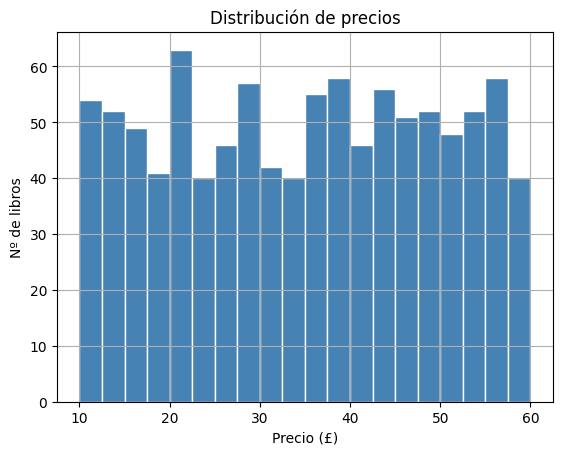

In [7]:
import pandas as pd 
import matplotlib.pyplot as plt
df = pd.read_csv("libros.csv")
#Estadísticas básicas
print(f"Precio medio: £{df['precio_num'].mean():.2f}") 
print(f"Más caro: {df.loc[df['precio_num'].idxmax(), 'titulo']}") 
print(df.groupby("rating")["precio_num"].mean().round(2))
#Histograma de precios
df["precio_num"].hist(bins=20, color="steelblue", edgecolor="white") 
plt.title("Distribución de precios") 
plt.xlabel("Precio (£)")
plt.ylabel("Nº de libros")
plt.savefig("precios.png") 
plt.show()

4 CONSULTAS EXTRA

In [8]:
top3=df.sort_values("precio_num").tail(3)
display(top3)

,titulo,precio,rating,stock,precio_num
860,Civilization and Its Discontents,Â£59.95,2,In stock,59.95
617,Last One Home (New Beginnings #1),Â£59.98,3,In stock,59.98
648,The Perfect Play (Play by Play #1),Â£59.99,3,In stock,59.99


In [9]:
print(f"Más barato: {df.loc[df['precio_num'].idxmin(), 'titulo']}")

Más barato: An Abundance of Katherines


In [10]:
Instock=df[df['stock'].str.contains('In stock', case=False, na=False)]
display(Instock)

,titulo,precio,rating,stock,precio_num
0,A Light in the Attic,Â£51.77,3,In stock,51.77
1,Tipping the Velvet,Â£53.74,1,In stock,53.74
2,Soumission,Â£50.10,1,In stock,50.10
3,Sharp Objects,Â£47.82,4,In stock,47.82
4,Sapiens: A Brief History of Humankind,Â£54.23,5,In stock,54.23
...,...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,Â£55.53,1,In stock,55.53
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",Â£57.06,4,In stock,57.06
997,A Spy's Devotion (The Regency Spies of London #1),Â£16.97,5,In stock,16.97
998,1st to Die (Women's Murder Club #1),Â£53.98,1,In stock,53.98


In [11]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# Configuración para asegurar que se vea en VS Code / Jupyter
pio.renderers.default = "notebook_connected"

# 1. Cargar tus datos
df = pd.read_csv('libros.csv')

# --- GRÁFICA 1: BARRAS INTERACTIVAS (Distribución de Ratings) ---
rating_counts = df['rating'].value_counts().reset_index()
rating_counts.columns = ['rating', 'cantidad']


fig_bar = px.bar(rating_counts, 
                 x='rating', 
                 y='cantidad', 
                 title="Cantidad de Libros por Valoración",
                 labels={'rating': 'Estrellas', 'cantidad': 'Nº de Libros'},
                 color='rating',
                 color_continuous_scale='Viridis')
fig_bar.show()



In [12]:
df = pd.read_csv('libros.csv')
fig = px.histogram(df, 
                   x="precio_num", 
                   marginal="box", 
                   nbins=30,
                   title="Análisis Interactivo de Precios y Cuantiles",
                   labels={'precio_num': 'Precio (£)'},
                   color_discrete_sequence=['#66b3ff'],
                   hover_data=["titulo"]) # Ver el título de libros específicos en los puntos

fig.update_layout(
    bargap=0.05,
    xaxis_title="Precio en Libras (£)",
    yaxis_title="Frecuencia (Cantidad de Libros)"
)

fig.show()